In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

#1. Load the dataset

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully.")
print(f"Shape of dataset: {df.shape}")
print(df.head())

Dataset loaded successfully.
Shape of dataset: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137

In [6]:
# 2. Data Cleaning
print("Checking for Missing Values")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Handle missing values
df = df.dropna()

# Outlier Detection
# Detect outliers in the 'Amount' feature using Z-score
df['Zscore_Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
df['Outlier'] = df['Zscore_Amount'].apply(lambda x: 1 if abs(x) > 3 else 0)
print(f"\nNumber of detected outliers: {df['Outlier'].sum()}")

# Optionally remove outliers
df = df[df['Outlier'] == 0].drop(columns=['Zscore_Amount', 'Outlier'])

Checking for Missing Values
Series([], dtype: int64)

Number of detected outliers: 6711


In [8]:
# 3. Data Transformation
print("Feature Scaling")
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop the original unscaled columns
df_scaled = df.drop(columns=['Amount', 'Time'])

print("Feature scaling completed.")
print(df_scaled[['Amount_Scaled', 'Time_Scaled']].head())

Feature Scaling
Feature scaling completed.
   Amount_Scaled  Time_Scaled
0       2.339235    -1.995772
1      -0.746123    -1.995772
3       1.790745    -1.995750
4       0.667098    -1.995729
5      -0.725544    -1.995729


In [9]:
# 4. Handling Class Imbalance
print("Balancing Dataset using SMOTE")
X = df_scaled.drop(columns=['Class'])
y = df_scaled['Class']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("SMOTE applied successfully.")
print(f"Before SMOTE: {y.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")

Balancing Dataset using SMOTE
SMOTE applied successfully.
Before SMOTE: {0: 257590, 1: 410}
After SMOTE: {0: 257590, 1: 257590}


In [10]:
# 5. Dimensionality Reduction using PCA
print("Applying PCA")
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_resampled)

pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
X_pca_df['Class'] = y_resampled.values

print("PCA completed. Transformed data shape:", X_pca_df.shape)
print(X_pca_df.head())

Applying PCA
PCA completed. Transformed data shape: (515180, 11)
         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0   9.942520 -1.053027  1.195001 -1.979163 -0.006555 -1.897524  1.985533   
1   9.984023 -0.862948  1.009251 -0.571955 -0.270012  0.716943  0.979063   
2  10.091527 -1.156454  1.456584 -1.960673 -0.148176 -1.129500  1.111155   
3   9.909246 -1.331455  1.373230 -1.798343  0.465469 -1.165637  1.704468   
4   9.884361 -0.996709  1.201875 -0.767745 -0.048077 -0.689987  1.337487   

        PC8       PC9      PC10  Class  
0 -1.034420 -1.049338 -0.968242      0  
1 -0.396851 -0.769847 -0.850949      0  
2 -1.329221  0.199386 -1.062689      0  
3 -1.046982 -0.118028  0.447124      0  
4 -1.647769 -0.092804 -0.604674      0  


In [13]:
# 6. Discretization Example
print("Discretizing Transaction Amount (Scaled) ")

min_val = df_scaled['Amount_Scaled'].min()
max_val = df_scaled['Amount_Scaled'].max()

bins = [min_val, -0.5, 0.5, max_val]  # bins within scaled range
labels = ['Low', 'Medium', 'High']

df_scaled['Amount_Category'] = pd.cut(df_scaled['Amount_Scaled'], bins=bins, labels=labels, include_lowest=True)

print(df_scaled[['Amount_Scaled', 'Amount_Category']].head())

Discretizing Transaction Amount (Scaled) 
   Amount_Scaled Amount_Category
0       2.339235            High
1      -0.746123             Low
3       1.790745            High
4       0.667098            High
5      -0.725544             Low


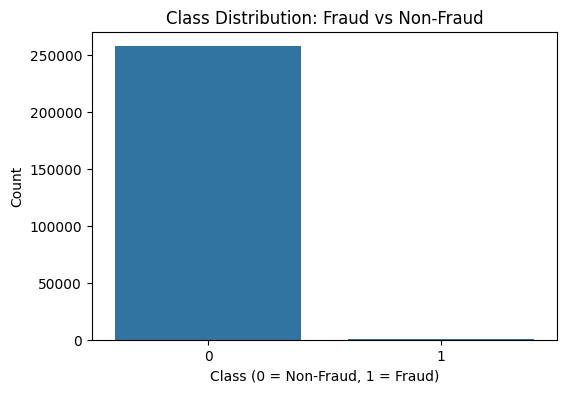

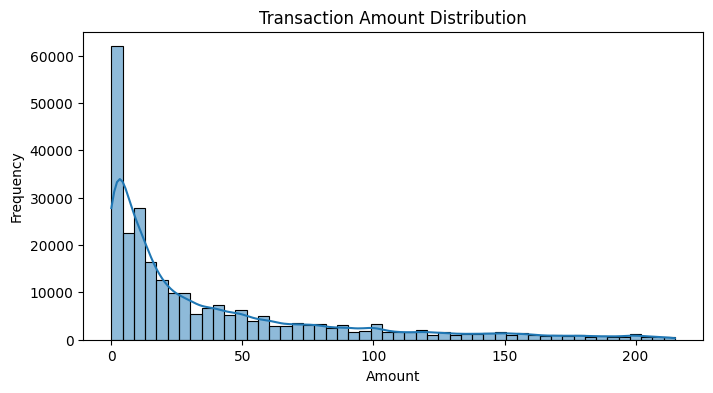

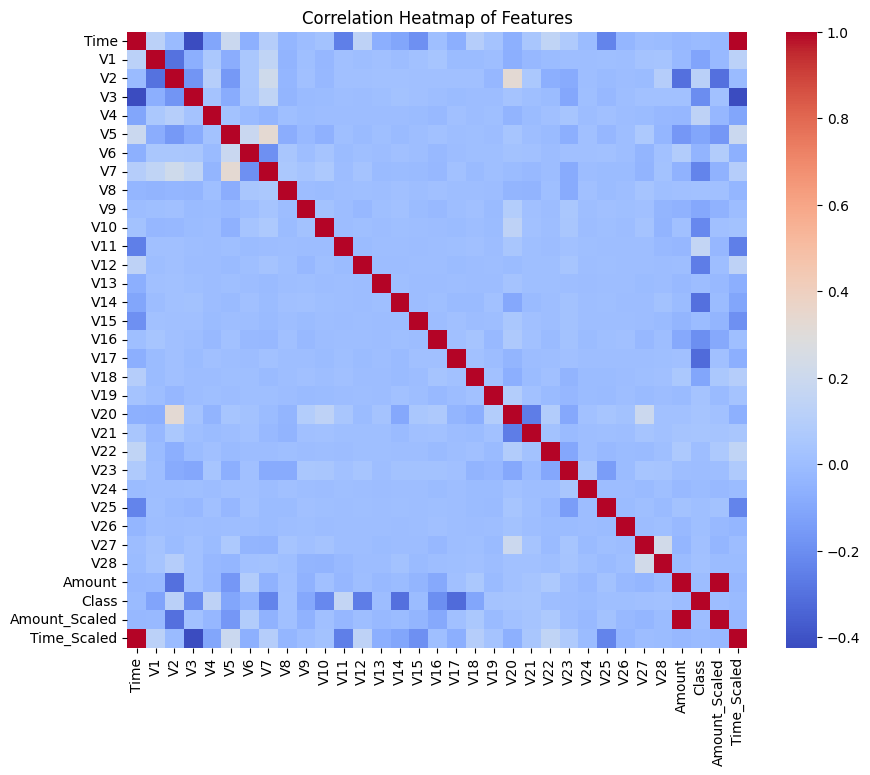

In [12]:
# 7. Data Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()